In [1]:
# =========================
# Phase 1.2 - MobileNetV2 Transfer Learning
# Setup and Paths
# =========================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import gc

# =========================
# Clear Runtime Memory Only
# =========================

tf.keras.backend.clear_session()
gc.collect()

# =========================
# Reproducibility
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# Project Paths
# =========================

PROJECT_DIR = Path("/content/drive/MyDrive/Calorify")
PHASE1_DIR = PROJECT_DIR / "phase1_clean"

SPLIT_DATA_DIR = PHASE1_DIR / "data" / "split"
METADATA_DIR = PHASE1_DIR / "metadata"
RESULTS_DIR = PHASE1_DIR / "results"
MODELS_DIR = PHASE1_DIR / "models"

train_dir = SPLIT_DATA_DIR / "train"
val_dir = SPLIT_DATA_DIR / "val"
test_dir = SPLIT_DATA_DIR / "test"

# MobileNetV2 specific outputs
MOBILENET_MODEL_PATH = MODELS_DIR / "mobilenetv2_transfer_learning.keras"
MOBILENET_HISTORY_PATH = RESULTS_DIR / "mobilenetv2_history.csv"

# =========================
# Load Class Names
# =========================

class_names_path = METADATA_DIR / "class_names.json"

with open(class_names_path, "r") as f:
    class_names = json.load(f)

NUM_CLASSES = len(class_names)

print("Project directory:", PROJECT_DIR)
print("Split data directory:", SPLIT_DATA_DIR)
print("Train directory:", train_dir)
print("Val directory:", val_dir)
print("Test directory:", test_dir)

print("\nClass names:")
print(class_names)

print("\nNumber of classes:", NUM_CLASSES)
print("\nMobileNetV2 model will be saved to:")
print(MOBILENET_MODEL_PATH)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Calorify
Split data directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split
Train directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/train
Val directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/val
Test directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/test

Class names:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']

Number of classes: 10

MobileNetV2 model will be saved to:
/content/drive/MyDrive/Calorify/phase1_clean/models/mobilenetv2_transfer_learning.keras


In [2]:
# =========================
# Cell 2 - Load TensorFlow Datasets + Class Weights
# =========================

import tensorflow as tf
import pandas as pd

# =========================
# Dataset Config
# =========================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# =========================
# Load Datasets from Prepared Split
# =========================

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =========================
# Prefetch for Performance
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDatasets loaded successfully.")

# =========================
# Load Class Weights
# =========================

class_weights_path = METADATA_DIR / "class_weights.csv"
class_weight_df = pd.read_csv(class_weights_path)

class_weight = {
    int(row["class_index"]): float(row["class_weight"])
    for _, row in class_weight_df.iterrows()
}

print("\nClass weights loaded from:")
print(class_weights_path)

display(class_weight_df)

print("\nclass_weight dictionary:")
print(class_weight)

Found 3413 files belonging to 10 classes.
Found 731 files belonging to 10 classes.
Found 732 files belonging to 10 classes.

Datasets loaded successfully.

Class weights loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/class_weights.csv


,class_index,class_name,train_count,class_weight
0,0,burger,350,0.975143
1,1,pizza,350,0.975143
2,2,fries,350,0.975143
3,3,pasta,350,0.975143
4,4,rice,301,1.133887
5,5,chicken,350,0.975143
6,6,salad,350,0.975143
7,7,sandwich,350,0.975143
8,8,sushi,312,1.093910
9,9,steak,350,0.975143



class_weight dictionary:
{0: 0.9751428571428572, 1: 0.9751428571428572, 2: 0.9751428571428572, 3: 0.9751428571428572, 4: 1.1338870431893688, 5: 0.9751428571428572, 6: 0.9751428571428572, 7: 0.9751428571428572, 8: 1.0939102564102563, 9: 0.9751428571428572}


Data augmentation layer created successfully.


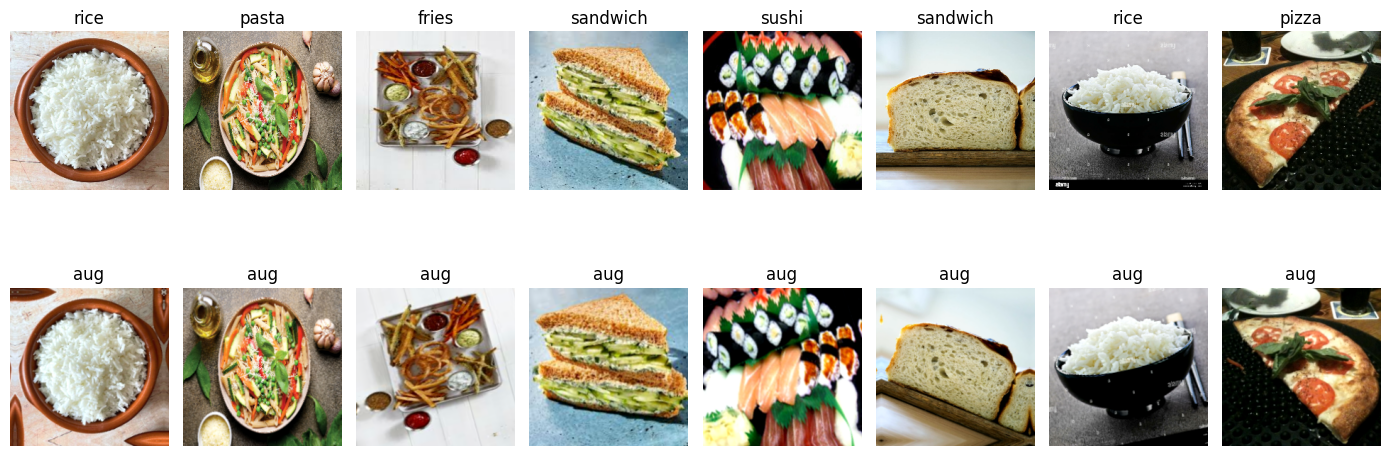

Sample image batch shape: (8, 224, 224, 3)
Sample label batch shape: (8, 10)


In [3]:
# =========================
# Cell 3 - Data Augmentation Preview for MobileNetV2
# =========================

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data Augmentation Layer
# =========================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="mobilenetv2_data_augmentation")

print("Data augmentation layer created successfully.")

# =========================
# Preview Original vs Augmented Images
# =========================

for images, labels in train_ds.take(1):
    sample_images = images[:8]
    sample_labels = labels[:8]
    augmented_images = data_augmentation(sample_images, training=True)

plt.figure(figsize=(14, 6))

for i in range(8):
    label_index = np.argmax(sample_labels[i].numpy())
    label_name = class_names[label_index]

    # Original image
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(label_name)
    plt.axis("off")

    # Augmented image
    ax = plt.subplot(2, 8, i + 9)
    aug_img = augmented_images[i].numpy()
    aug_img = np.clip(aug_img, 0, 255).astype("uint8")
    plt.imshow(aug_img)
    plt.title("aug")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample image batch shape:", sample_images.shape)
print("Sample label batch shape:", sample_labels.shape)

In [4]:
# =========================
# Cell 4 - Build MobileNetV2 Transfer Learning Model
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =========================
# MobileNetV2 Config
# =========================

IMAGE_SHAPE = (224, 224, 3)
LEARNING_RATE_MOBILENET = 1e-3
EPOCHS_MOBILENET = 15

print("Building MobileNetV2 transfer learning model...")
print("Number of classes:", NUM_CLASSES)

# =========================
# Load Pretrained Base Model
# =========================

base_model = MobileNetV2(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers first
base_model.trainable = False

print("MobileNetV2 base model loaded with ImageNet weights.")
print("Base model trainable:", base_model.trainable)

# =========================
# Build Full Model
# =========================

inputs = layers.Input(shape=IMAGE_SHAPE, name="input_image")

# Data augmentation only active during training
x = data_augmentation(inputs)

# MobileNetV2-specific preprocessing
# Converts image values from [0, 255] to the format expected by MobileNetV2
x = layers.Lambda(preprocess_input, name="mobilenetv2_preprocessing")(x)

# Pretrained MobileNetV2 feature extractor
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.BatchNormalization(name="head_batch_norm")(x)
x = layers.Dropout(0.4, name="head_dropout")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="food_class_output"
)(x)

mobilenet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_TransferLearning"
)

# =========================
# Compile Model
# =========================

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_MOBILENET),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Building MobileNetV2 transfer learning model...
Number of classes: 10
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base model loaded with ImageNet weights.
Base model trainable: False


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_data_augmentation   │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_class_output (Dense)       │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [5]:
# =========================
# Cell 5 - Train MobileNetV2 Frozen Base
# =========================

import pandas as pd
import tensorflow as tf

# =========================
# MobileNetV2 Callbacks
# =========================

mobilenet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MOBILENET_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# Train MobileNetV2 Head
# =========================

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MOBILENET,
    callbacks=mobilenet_callbacks,
    class_weight=class_weight
)

# =========================
# Save Training History
# =========================

mobilenet_history_df = pd.DataFrame(mobilenet_history.history)
mobilenet_history_df.to_csv(MOBILENET_HISTORY_PATH, index=False)

print("MobileNetV2 frozen-base training completed.")
print("MobileNetV2 model saved to:")
print(MOBILENET_MODEL_PATH)

print("\nMobileNetV2 history saved to:")
print(MOBILENET_HISTORY_PATH)

display(mobilenet_history_df)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5762 - loss: 1.4382
Epoch 1: val_loss improved from None to 0.65869, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/mobilenetv2_transfer_learning.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/mobilenetv2_transfer_learning.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 520s 5s/step - accuracy: 0.6950 - loss: 1.0089 - val_accuracy: 0.7907 - val_loss: 0.6587 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8190 - loss: 0.5466
Epoch 2: val_loss improved from 0.65869 to 0.57362, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/mobilenetv2_transfer_learning.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/mobilenetv2_transfer_learning.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8119 - loss: 0.5842 - val_accuracy: 0.8304 - val_loss: 0.5736 - learning_rate

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.694990,1.008855,0.790698,0.658685,0.00100
1,0.811896,0.584248,0.830369,0.573620,0.00100
2,0.842953,0.476118,0.837209,0.550505,0.00100
3,0.855845,0.419615,0.837209,0.534885,0.00100
4,0.880457,0.370170,0.820793,0.586946,0.00100
5,0.885731,0.346243,0.819425,0.610692,0.00100
6,0.911222,0.277103,0.824897,0.557707,0.00050
7,0.908585,0.264082,0.856361,0.518240,0.00050
8,0.930853,0.227371,0.839945,0.527079,0.00050
9,0.926751,0.224397,0.838577,0.531183,0.00050


In [9]:
# =========================
# Evaluate Current MobileNetV2 Model on Test Set
# =========================

test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)

print("MobileNetV2 Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.8552 - loss: 0.4767
MobileNetV2 Test Results
Test Loss: 0.4767
Test Accuracy: 0.8552


In [10]:
# =========================
# Save MobileNetV2 Weights Safely
# =========================

MOBILENET_WEIGHTS_PATH = MODELS_DIR / "mobilenetv2_transfer_learning.weights.h5"

mobilenet_model.save_weights(MOBILENET_WEIGHTS_PATH)

print("MobileNetV2 weights saved safely to:")
print(MOBILENET_WEIGHTS_PATH)

MobileNetV2 weights saved safely to:
/content/drive/MyDrive/Calorify/phase1_clean/models/mobilenetv2_transfer_learning.weights.h5


MobileNetV2 training history loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.694990,1.008855,0.790698,0.658685,0.00100
1,0.811896,0.584248,0.830369,0.573620,0.00100
2,0.842953,0.476118,0.837209,0.550505,0.00100
3,0.855845,0.419615,0.837209,0.534885,0.00100
4,0.880457,0.370170,0.820793,0.586946,0.00100
5,0.885731,0.346243,0.819425,0.610692,0.00100
6,0.911222,0.277103,0.824897,0.557707,0.00050
7,0.908585,0.264082,0.856361,0.518240,0.00050
8,0.930853,0.227371,0.839945,0.527079,0.00050
9,0.926751,0.224397,0.838577,0.531183,0.00050


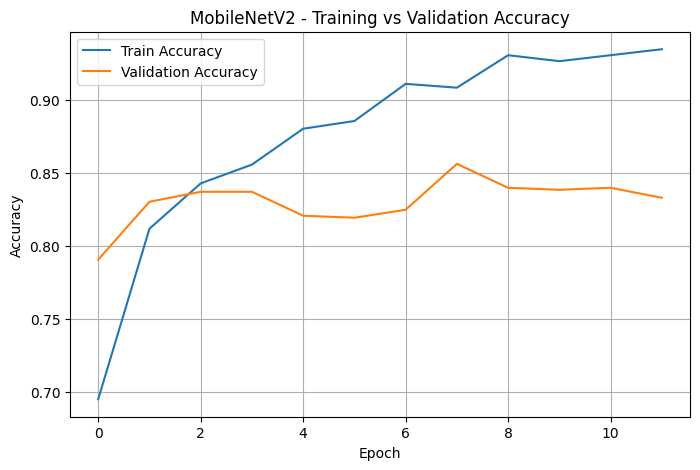

Accuracy curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_accuracy_curve.png


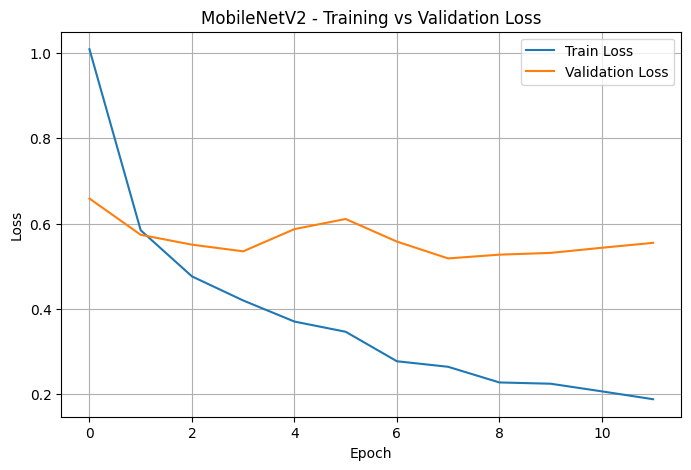

Loss curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_loss_curve.png


In [11]:
# =========================
# Cell 7 - MobileNetV2 Training Curves
# =========================

import pandas as pd
import matplotlib.pyplot as plt

# Load MobileNetV2 history
mobilenet_history_df = pd.read_csv(MOBILENET_HISTORY_PATH)

print("MobileNetV2 training history loaded from:")
print(MOBILENET_HISTORY_PATH)

display(mobilenet_history_df)

# =========================
# Accuracy Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(mobilenet_history_df["accuracy"], label="Train Accuracy")
plt.plot(mobilenet_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

mobilenet_accuracy_curve_path = RESULTS_DIR / "mobilenetv2_accuracy_curve.png"
plt.savefig(mobilenet_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:")
print(mobilenet_accuracy_curve_path)

# =========================
# Loss Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(mobilenet_history_df["loss"], label="Train Loss")
plt.plot(mobilenet_history_df["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

mobilenet_loss_curve_path = RESULTS_DIR / "mobilenetv2_loss_curve.png"
plt.savefig(mobilenet_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved to:")
print(mobilenet_loss_curve_path)

Using MobileNetV2 model currently in memory with best restored weights.
MobileNetV2 classification report saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_classification_report.csv


,precision,recall,f1-score,support
burger,0.916667,0.880000,0.897959,75.000000
pizza,0.945946,0.933333,0.939597,75.000000
fries,0.943662,0.893333,0.917808,75.000000
pasta,0.808219,0.786667,0.797297,75.000000
rice,0.843750,0.830769,0.837209,65.000000
chicken,0.743902,0.813333,0.777070,75.000000
salad,0.918919,0.906667,0.912752,75.000000
sandwich,0.830986,0.786667,0.808219,75.000000
sushi,0.816901,0.865672,0.840580,67.000000
steak,0.800000,0.853333,0.825806,75.000000


MobileNetV2 confusion matrix CSV saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_confusion_matrix.csv


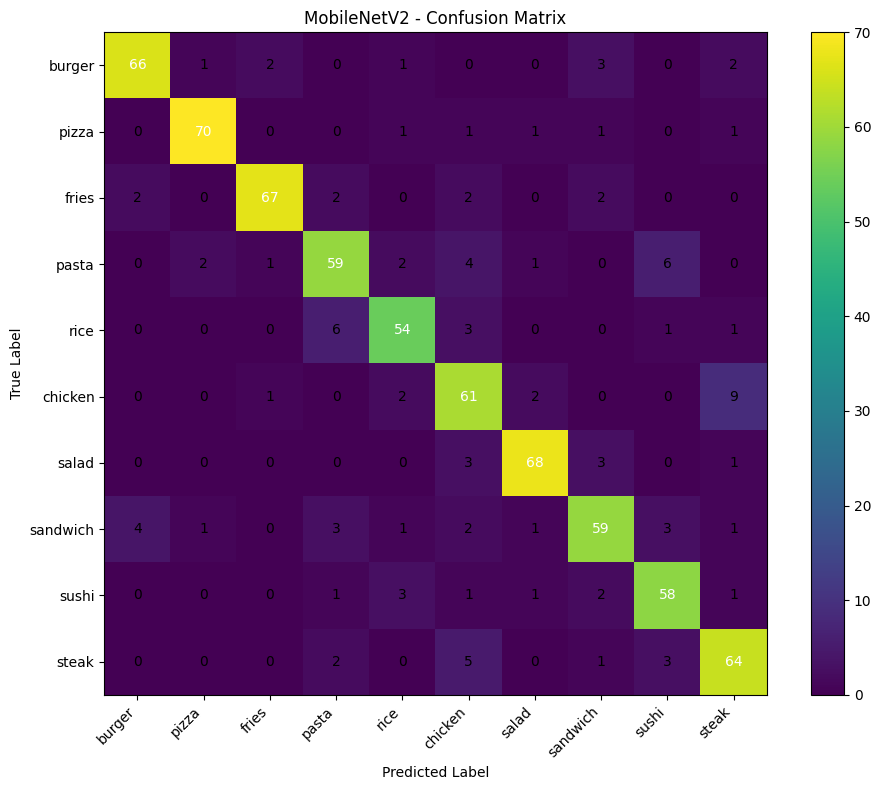

MobileNetV2 confusion matrix image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_confusion_matrix.png


In [12]:
# =========================
# Cell 8 - MobileNetV2 Classification Report + Confusion Matrix
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# Use the current MobileNetV2 model in memory
# It already restored best weights from Epoch 8 using EarlyStopping
best_mobilenet_model = mobilenet_model

print("Using MobileNetV2 model currently in memory with best restored weights.")

# =========================
# Collect True Labels and Predictions
# =========================

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_mobilenet_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)

    y_true.extend(true_indices)
    y_pred.extend(pred_indices)
    y_prob.extend(np.max(probabilities, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================
# Classification Report
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

mobilenet_report_df = pd.DataFrame(report_dict).transpose()

mobilenet_report_path = RESULTS_DIR / "mobilenetv2_classification_report.csv"
mobilenet_report_df.to_csv(mobilenet_report_path)

print("MobileNetV2 classification report saved to:")
print(mobilenet_report_path)

display(mobilenet_report_df)

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

mobilenet_cm_csv_path = RESULTS_DIR / "mobilenetv2_confusion_matrix.csv"
cm_df.to_csv(mobilenet_cm_csv_path)

print("MobileNetV2 confusion matrix CSV saved to:")
print(mobilenet_cm_csv_path)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("MobileNetV2 - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()

mobilenet_cm_png_path = RESULTS_DIR / "mobilenetv2_confusion_matrix.png"
plt.savefig(mobilenet_cm_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("MobileNetV2 confusion matrix image saved to:")
print(mobilenet_cm_png_path)

MobileNetV2 wrong predictions saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_wrong_predictions.csv

Number of wrong predictions: 106
Number of correct predictions: 626


,image_path,true_class,predicted_class,confidence,is_correct
0,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,fries,0.277097,False
1,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sandwich,0.879978,False
2,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,fries,0.433085,False
3,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sandwich,0.732538,False
4,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,pizza,0.382358,False
5,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,rice,0.415239,False
6,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,steak,0.305377,False
7,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,steak,0.766327,False
8,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sandwich,0.738163,False
9,/content/drive/MyDrive/Calorify/phase1_clean/d...,pizza,steak,0.537259,False


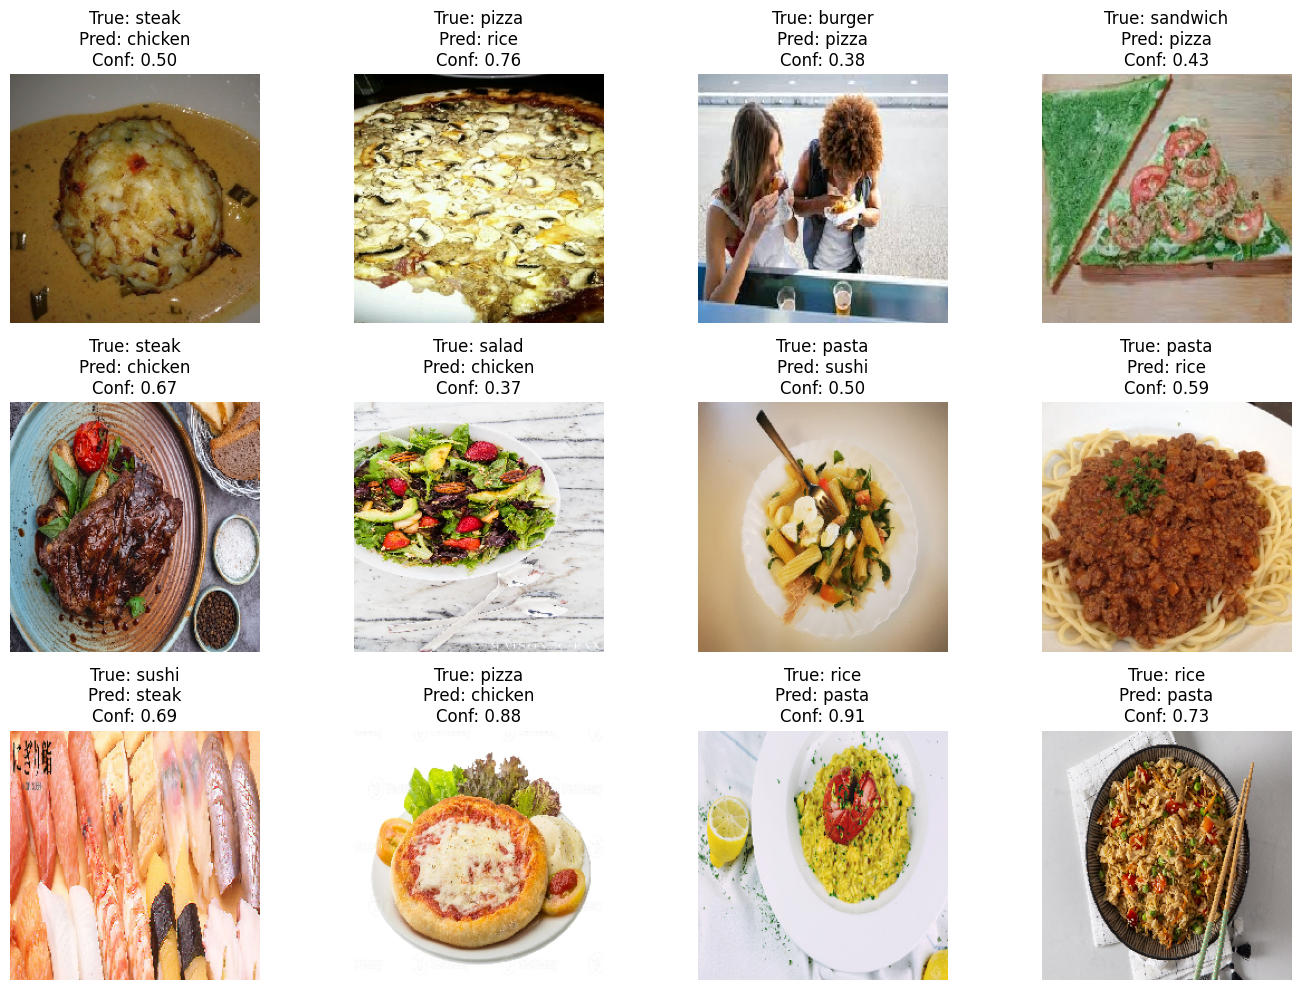

MobileNetV2 wrong prediction samples image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_wrong_prediction_samples.png


In [13]:
# =========================
# Cell 9 - MobileNetV2 Wrong Prediction Samples
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use current MobileNetV2 model in memory
best_mobilenet_model = mobilenet_model

wrong_records = []
correct_records = []

# Collect file paths from test directory in the same order as test_ds
test_image_paths = []

for class_name in class_names:
    class_dir = test_dir / class_name
    class_files = sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
    ])
    test_image_paths.extend(class_files)

sample_index = 0

for images, labels in test_ds:
    probabilities = best_mobilenet_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    for i in range(len(images)):
        true_class = class_names[true_indices[i]]
        predicted_class = class_names[pred_indices[i]]
        confidence = float(confidences[i])

        image_path = str(test_image_paths[sample_index]) if sample_index < len(test_image_paths) else ""

        record = {
            "image_path": image_path,
            "true_class": true_class,
            "predicted_class": predicted_class,
            "confidence": confidence,
            "is_correct": true_class == predicted_class
        }

        if true_class == predicted_class:
            correct_records.append(record)
        else:
            wrong_records.append(record)

        sample_index += 1

mobilenet_wrong_df = pd.DataFrame(wrong_records)
mobilenet_correct_df = pd.DataFrame(correct_records)

mobilenet_wrong_predictions_path = RESULTS_DIR / "mobilenetv2_wrong_predictions.csv"
mobilenet_wrong_df.to_csv(mobilenet_wrong_predictions_path, index=False)

print("MobileNetV2 wrong predictions saved to:")
print(mobilenet_wrong_predictions_path)

print("\nNumber of wrong predictions:", len(mobilenet_wrong_df))
print("Number of correct predictions:", len(mobilenet_correct_df))

display(mobilenet_wrong_df.head(20))

# =========================
# Show Sample Wrong Predictions
# =========================

sample_wrong_df = mobilenet_wrong_df.sample(
    n=min(12, len(mobilenet_wrong_df)),
    random_state=42
).reset_index(drop=True)

plt.figure(figsize=(14, 10))

for i, row in sample_wrong_df.iterrows():
    img_path = row["image_path"]

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img_array)
    plt.title(
        f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()

mobilenet_wrong_samples_path = RESULTS_DIR / "mobilenetv2_wrong_prediction_samples.png"
plt.savefig(mobilenet_wrong_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("MobileNetV2 wrong prediction samples image saved to:")
print(mobilenet_wrong_samples_path)

In [14]:
# =========================
# Cell 10 - Save MobileNetV2 Final Summary
# =========================

import pandas as pd

mobilenet_summary = {
    "model_name": "MobileNetV2 Transfer Learning",
    "model_type": "Pretrained CNN / Transfer Learning",
    "training_strategy": "Frozen MobileNetV2 base + custom classification head",
    "weights_file": str(MOBILENET_WEIGHTS_PATH),
    "history_file": str(MOBILENET_HISTORY_PATH),
    "test_accuracy": 0.8552,
    "test_loss": 0.4767,
    "best_validation_accuracy": 0.856361,
    "best_validation_loss": 0.518240,
    "best_epoch": 8,
    "macro_f1_score": 0.855430,
    "weighted_f1_score": 0.855841,
    "correct_predictions": 626,
    "wrong_predictions": 106,
    "status": "Completed",
    "notes": (
        "MobileNetV2 significantly outperformed the Custom CNN baseline. "
        "The model achieved strong test accuracy and high F1-scores across most classes. "
        "Remaining errors mainly occurred in visually similar or noisy samples such as "
        "steak/chicken, rice/pasta, and sandwich/pizza."
    )
}

mobilenet_summary_df = pd.DataFrame([mobilenet_summary])

mobilenet_summary_csv_path = RESULTS_DIR / "mobilenetv2_final_summary.csv"
mobilenet_summary_txt_path = RESULTS_DIR / "mobilenetv2_final_summary.txt"

mobilenet_summary_df.to_csv(mobilenet_summary_csv_path, index=False)

with open(mobilenet_summary_txt_path, "w", encoding="utf-8") as f:
    for key, value in mobilenet_summary.items():
        f.write(f"{key}: {value}\n")

print("MobileNetV2 final summary saved to:")
print(mobilenet_summary_csv_path)
print(mobilenet_summary_txt_path)

display(mobilenet_summary_df)

MobileNetV2 final summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_final_summary.csv
/content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_final_summary.txt


,model_name,model_type,training_strategy,weights_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,best_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,MobileNetV2 Transfer Learning,Pretrained CNN / Transfer Learning,Frozen MobileNetV2 base + custom classificatio...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.8552,0.4767,0.856361,0.51824,8,0.85543,0.855841,626,106,Completed,MobileNetV2 significantly outperformed the Cus...


In [19]:
# Final Summary — MobileNetV2 Transfer Learning

#In this notebook, MobileNetV2 was used as the second Phase 1 image classification model after the Custom CNN baseline. The same prepared train, validation, and test split was used to ensure fair comparison.

#MobileNetV2 was loaded with pretrained ImageNet weights and used as a frozen feature extractor. A custom classification head was added on top of the pretrained base model for the 10 food classes.

#The model achieved:

#- Best Validation Accuracy: 85.64%
#- Best Validation Loss: 0.5182
#- Test Accuracy: 85.52%
#- Test Loss: 0.4767
#- Macro F1-score: 85.54%
#- Weighted F1-score: 85.58%
#- Correct Predictions: 626
#- Wrong Predictions: 106

#Compared with the Custom CNN baseline, MobileNetV2 achieved a major improvement. The Custom CNN achieved around 50.55% test accuracy, while MobileNetV2 achieved 85.52% test accuracy. This confirms that transfer learning provides much stronger visual feature extraction than training a CNN from scratch on the scraped food dataset.

#The confusion matrix showed strong performance across most classes, especially pizza, fries, salad, and burger. Remaining errors mainly occurred between visually similar or noisy classes such as chicken/steak, rice/pasta, and sandwich/pizza.

#Overall, MobileNetV2 is currently the strongest model tested so far in Phase 1.